### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from sklearn.metrics import roc_auc_score
from sklearn.feature_selection import mutual_info_classif
import warnings
warnings.filterwarnings("ignore")

INTEGRATED_PATH = "../data/integrated/algeria_wildfire_dataset.parquet"
OUT_DIR = Path("outputs/eda")
OUT_DIR.mkdir(parents=True, exist_ok=True)

RISK_LABELS = {0: "NO_FIRE", 1: "ACTIVE", 2: "SIGNIFICANT"}
COLORS      = {0: "#2d6a4f", 1: "#f4a261", 2: "#c1121f"}
palette     = [COLORS[i] for i in range(3)]

df = pd.read_parquet(INTEGRATED_PATH)

### Temporal Patterns

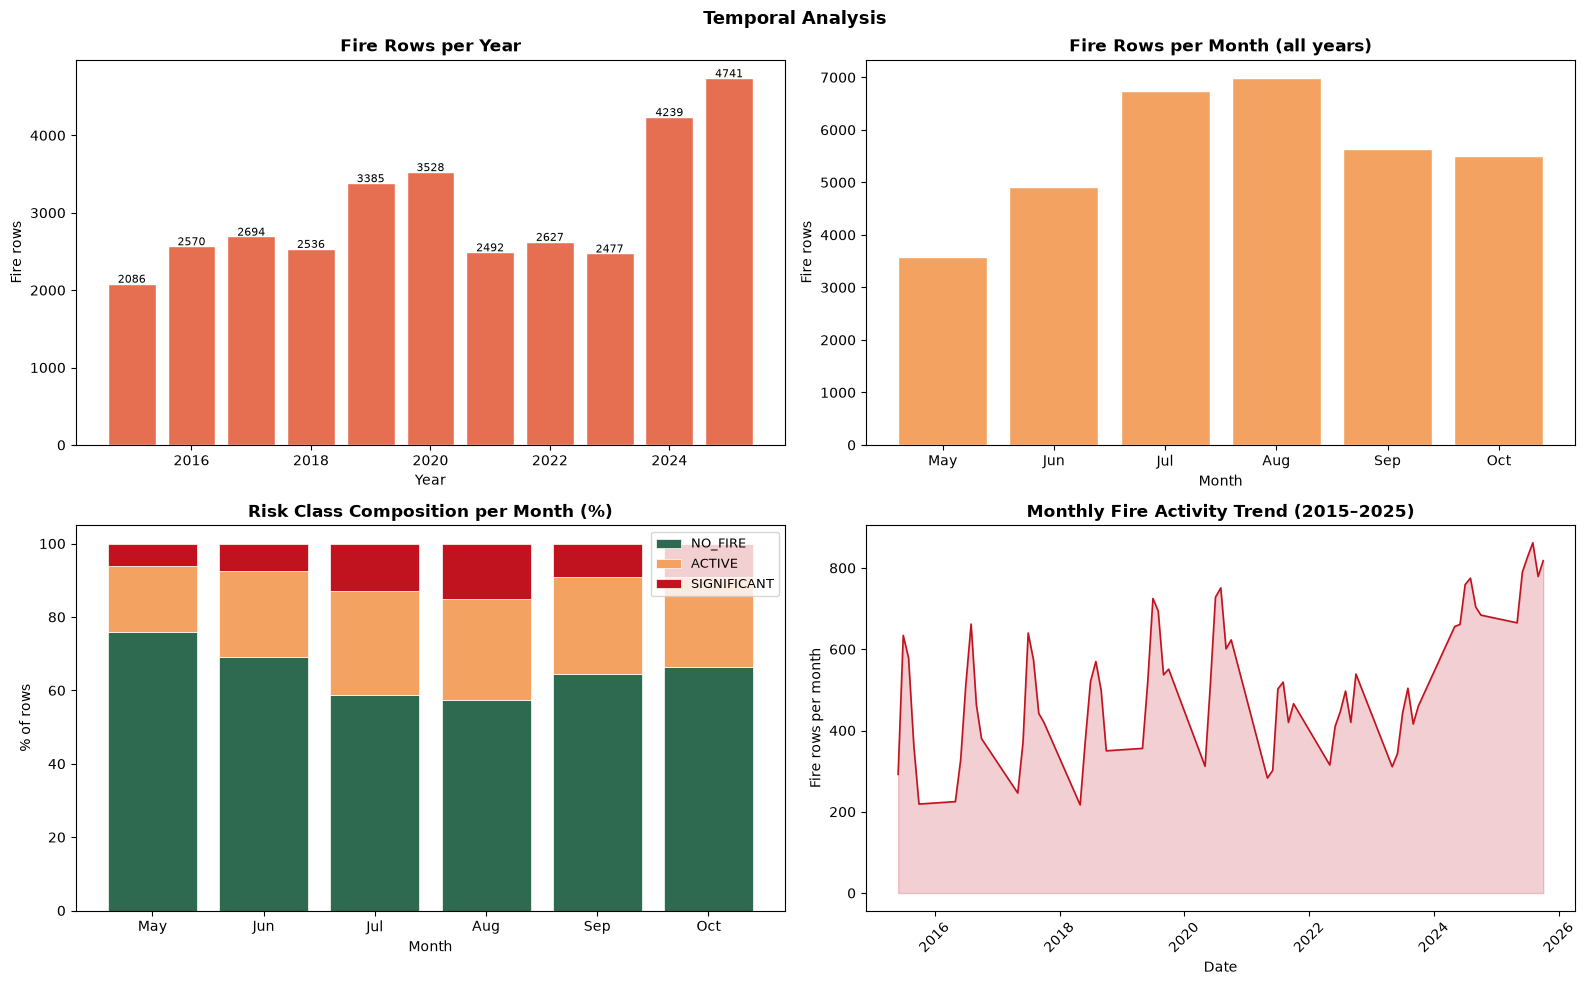

In [2]:
month_names = {5:"May", 6:"Jun", 7:"Jul", 8:"Aug", 9:"Sep", 10:"Oct"}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Fire rows per year
yearly = df[df["fire_risk_class"] > 0].groupby("year").size()
axes[0,0].bar(yearly.index, yearly.values, color="#e76f51", edgecolor="white")
axes[0,0].set_title("Fire Rows per Year", fontweight="bold")
axes[0,0].set_xlabel("Year"); axes[0,0].set_ylabel("Fire rows")
for bar, val in zip(axes[0,0].patches, yearly.values):
    axes[0,0].text(bar.get_x()+bar.get_width()/2,
                   bar.get_height()+10, str(val), ha="center", fontsize=8)

# Fire rows per month
monthly = df[df["fire_risk_class"] > 0].groupby("month").size()
axes[0,1].bar([month_names.get(m, m) for m in monthly.index],
              monthly.values, color="#f4a261", edgecolor="white")
axes[0,1].set_title("Fire Rows per Month (all years)", fontweight="bold")
axes[0,1].set_xlabel("Month"); axes[0,1].set_ylabel("Fire rows")

# Class composition per month — stacked bar
month_class = df.groupby(["month","fire_risk_class"]).size().unstack(fill_value=0)
month_class_pct = month_class.div(month_class.sum(axis=1), axis=0) * 100
bottom = np.zeros(len(month_class_pct))
for cls in range(3):
    if cls in month_class_pct.columns:
        axes[1,0].bar([month_names.get(m,m) for m in month_class_pct.index],
                      month_class_pct[cls].values, bottom=bottom,
                      color=COLORS[cls], label=RISK_LABELS[cls],
                      edgecolor="white", linewidth=0.5)
        bottom += month_class_pct[cls].values
axes[1,0].set_title("Risk Class Composition per Month (%)", fontweight="bold")
axes[1,0].set_xlabel("Month"); axes[1,0].set_ylabel("% of rows")
axes[1,0].legend(loc="upper right", fontsize=9)

# Monthly trend over time
df["year_month"] = df["date"].dt.to_period("M")
trend = df[df["fire_risk_class"] > 0].groupby("year_month").size()
axes[1,1].plot(trend.index.to_timestamp(), trend.values,
               color="#c1121f", linewidth=1.2)
axes[1,1].fill_between(trend.index.to_timestamp(),
                        trend.values, alpha=0.2, color="#c1121f")
axes[1,1].set_title("Monthly Fire Activity Trend (2015–2025)", fontweight="bold")
axes[1,1].set_xlabel("Date"); axes[1,1].set_ylabel("Fire rows per month")
axes[1,1].tick_params(axis="x", rotation=45)

plt.suptitle("Temporal Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "02_temporal_patterns.png", dpi=150)
plt.show()

### Spatial Patterns

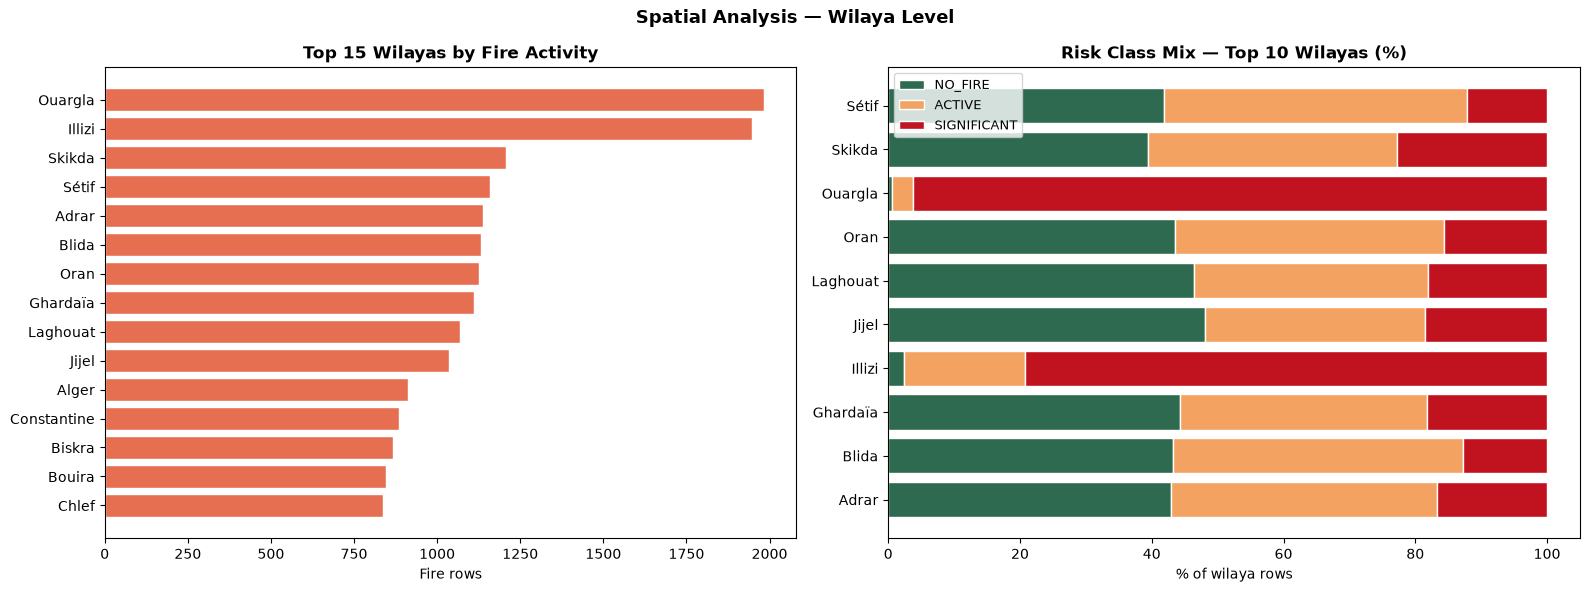

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 wilayas by fire activity
top_wilayas = (df[df["fire_risk_class"] > 0]
               .groupby("wilaya_name").size()
               .sort_values(ascending=False)
               .head(15))
axes[0].barh(top_wilayas.index[::-1], top_wilayas.values[::-1],
             color="#e76f51", edgecolor="white")
axes[0].set_title("Top 15 Wilayas by Fire Activity", fontweight="bold")
axes[0].set_xlabel("Fire rows")

# Class breakdown for top 10 wilayas
top10 = top_wilayas.head(10).index.tolist()
top10_df = df[df["wilaya_name"].isin(top10)]
breakdown = (top10_df.groupby(["wilaya_name","fire_risk_class"])
             .size().unstack(fill_value=0))
breakdown_pct = breakdown.div(breakdown.sum(axis=1), axis=0) * 100
bottom = np.zeros(len(breakdown_pct))
for cls in range(3):
    if cls in breakdown_pct.columns:
        axes[1].barh(breakdown_pct.index,
                     breakdown_pct[cls].values,
                     left=bottom, color=COLORS[cls],
                     label=RISK_LABELS[cls], edgecolor="white")
        bottom += breakdown_pct[cls].values
axes[1].set_title("Risk Class Mix — Top 10 Wilayas (%)", fontweight="bold")
axes[1].set_xlabel("% of wilaya rows")
axes[1].legend(fontsize=9)

plt.suptitle("Spatial Analysis — Wilaya Level", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "03_spatial_patterns.png", dpi=150)
plt.show()

### Feature Distribution by Class

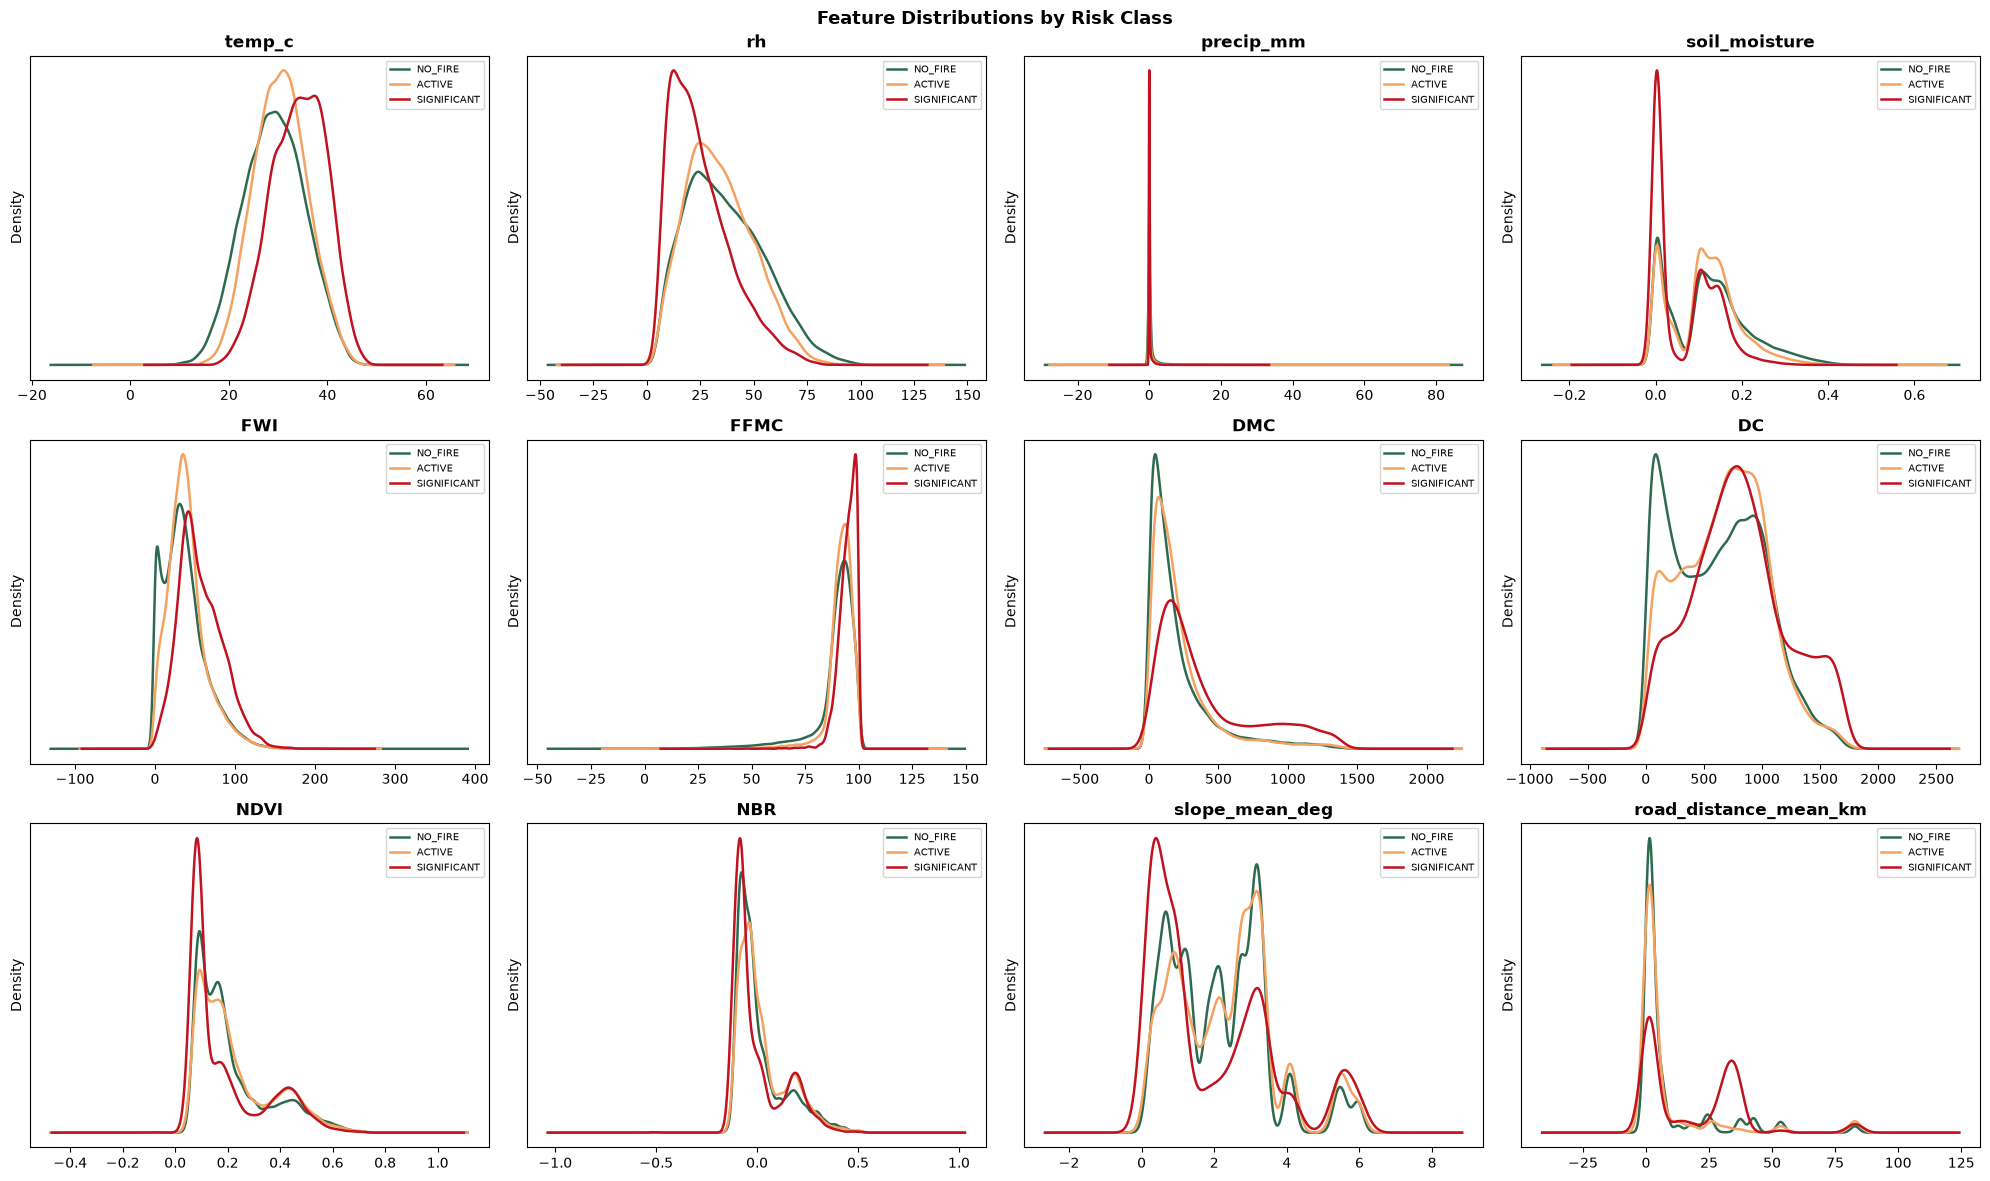

In [4]:
features = ["temp_c", "rh", "precip_mm", "soil_moisture",
            "FWI", "FFMC", "DMC", "DC",
            "NDVI", "NBR", "slope_mean_deg", "road_distance_mean_km"]

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for ax, feat in zip(axes, features):
    for cls in range(3):
        subset = df[df["fire_risk_class"] == cls][feat].dropna()
        if len(subset) > 0:
            subset.plot.kde(ax=ax, label=RISK_LABELS[cls],
                            color=COLORS[cls], linewidth=1.8)
    ax.set_title(feat, fontweight="bold")
    ax.set_xlabel("")
    ax.legend(fontsize=7)
    ax.set_yticks([])

plt.suptitle("Feature Distributions by Risk Class", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "04_feature_distributions.png", dpi=150)
plt.show()

### Correlation Heatmap

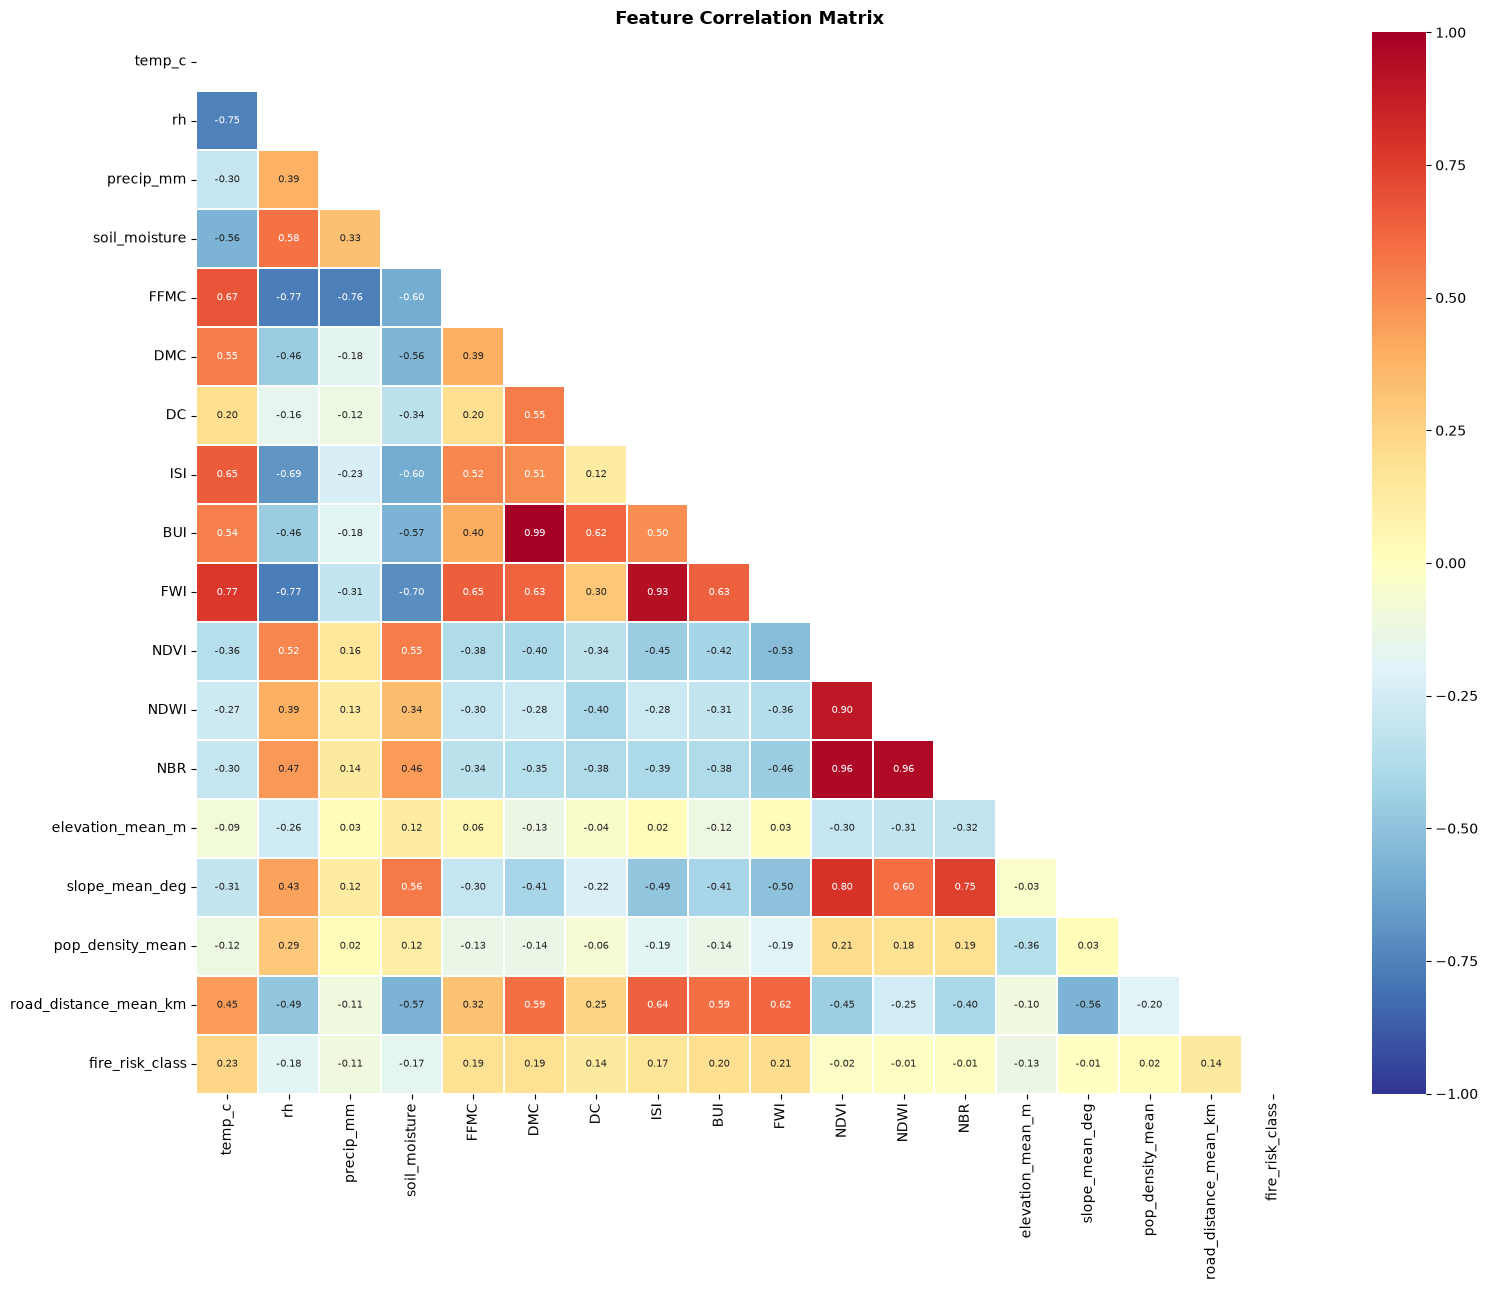


Top correlations with fire_risk_class:
temp_c                   0.235
FWI                      0.207
BUI                      0.196
DMC                      0.191
FFMC                     0.186
rh                       0.184
ISI                      0.167
soil_moisture            0.165
DC                       0.138
road_distance_mean_km    0.137
elevation_mean_m         0.128
precip_mm                0.109
NDVI                     0.019
pop_density_mean         0.016
NDWI                     0.014
NBR                      0.009
slope_mean_deg           0.007


In [5]:
feature_cols = [
    "temp_c", "rh", "precip_mm", "soil_moisture",
    "FFMC", "DMC", "DC", "ISI", "BUI", "FWI",
    "NDVI", "NDWI", "NBR",
    "elevation_mean_m", "slope_mean_deg",
    "pop_density_mean", "road_distance_mean_km",
    "fire_risk_class"
]
feature_cols = [c for c in feature_cols if c in df.columns]
corr = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdYlBu_r", center=0, vmin=-1, vmax=1,
            ax=ax, annot_kws={"size": 7}, linewidths=0.3)
ax.set_title("Feature Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "05_correlation_heatmap.png", dpi=150)
plt.show()

print("\nTop correlations with fire_risk_class:")
target_corr = (corr["fire_risk_class"]
               .drop("fire_risk_class")
               .abs()
               .sort_values(ascending=False))
print(target_corr.round(3).to_string())

### FWI discriminative power

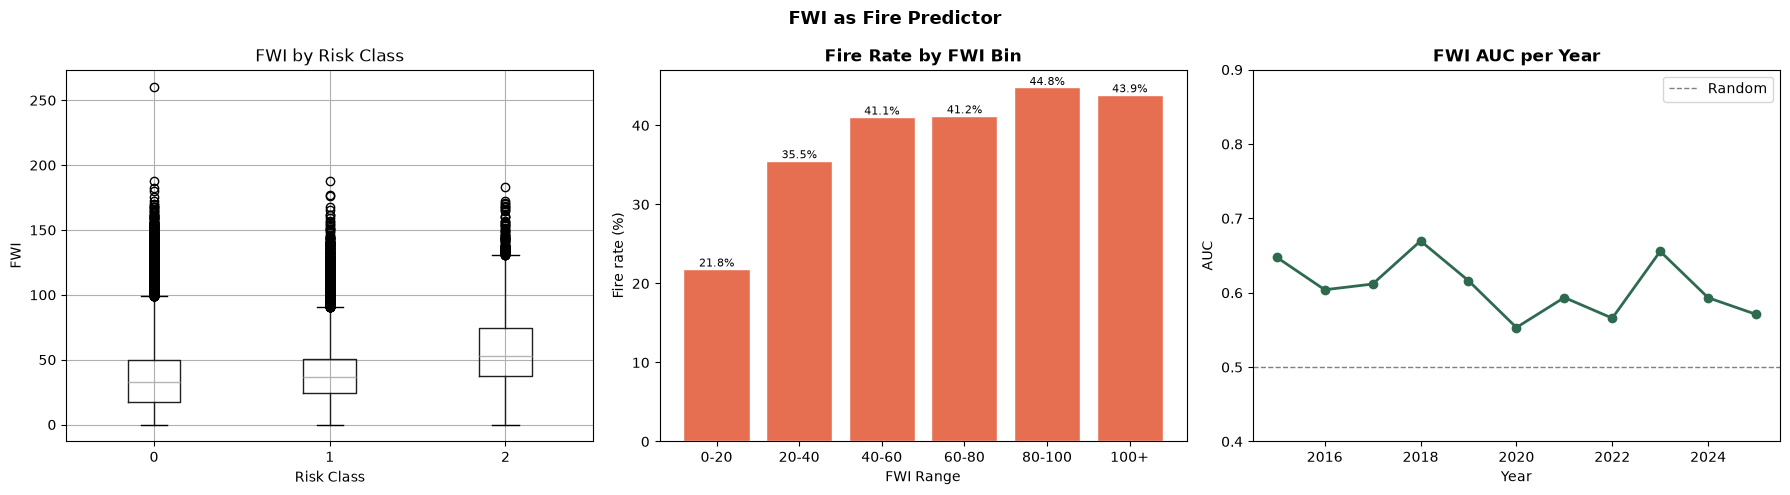


AUC per year:
  2015: 0.648
  2016: 0.604
  2017: 0.612
  2018: 0.670
  2019: 0.616
  2020: 0.553
  2021: 0.594
  2022: 0.566
  2023: 0.656
  2024: 0.593
  2025: 0.571


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Boxplot
df.boxplot(column="FWI", by="fire_risk_class", ax=axes[0])
axes[0].set_title("FWI by Risk Class")
axes[0].set_xlabel("Risk Class"); axes[0].set_ylabel("FWI")
plt.sca(axes[0]); plt.title("FWI by Risk Class")

# Fire rate by FWI bin
bins       = [0, 20, 40, 60, 80, 100, 300]
bin_labels = ["0-20","20-40","40-60","60-80","80-100","100+"]
df["fwi_bin"] = pd.cut(df["FWI"], bins=bins, labels=bin_labels)
bin_stats = df.groupby("fwi_bin", observed=True).agg(
    total=("fire_risk_class","count"),
    fire=("fire_risk_class", lambda x: (x > 0).sum())
).assign(fire_rate=lambda x: x["fire"]/x["total"]*100)

axes[1].bar(bin_stats.index, bin_stats["fire_rate"],
            color="#e76f51", edgecolor="white")
axes[1].set_title("Fire Rate by FWI Bin", fontweight="bold")
axes[1].set_xlabel("FWI Range"); axes[1].set_ylabel("Fire rate (%)")
for bar, val in zip(axes[1].patches, bin_stats["fire_rate"]):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.3,
                 f"{val:.1f}%", ha="center", fontsize=8)

# AUC per year
aucs = {}
for year, grp in df.groupby("year"):
    y = (grp["fire_risk_class"] > 0).astype(int)
    if y.sum() > 0 and y.sum() < len(y):
        aucs[year] = roc_auc_score(y, grp["FWI"])
axes[2].plot(list(aucs.keys()), list(aucs.values()),
             marker="o", color="#2d6a4f", linewidth=2, markersize=6)
axes[2].axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Random")
axes[2].set_title("FWI AUC per Year", fontweight="bold")
axes[2].set_xlabel("Year"); axes[2].set_ylabel("AUC")
axes[2].set_ylim(0.4, 0.9); axes[2].legend()

plt.suptitle("FWI as Fire Predictor", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "06_fwi_analysis.png", dpi=150)
plt.show()

print("\nAUC per year:")
for y, auc in aucs.items():
    print(f"  {y}: {auc:.3f}")

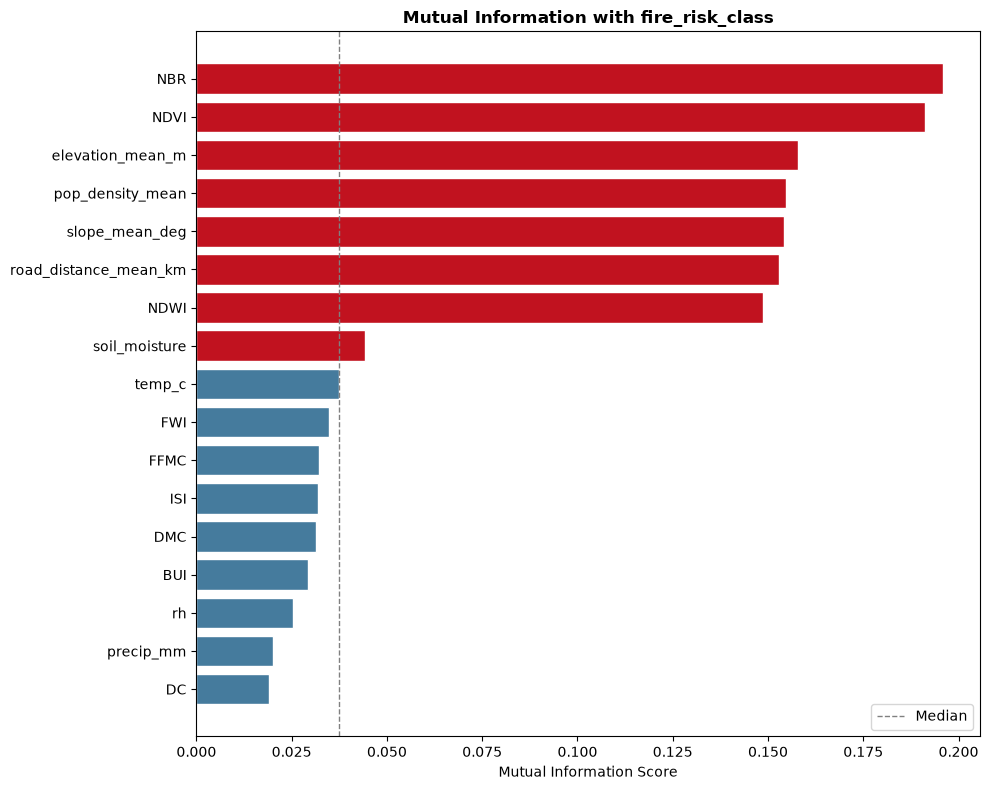


MI scores (descending):
NBR                      0.1958
NDVI                     0.1912
elevation_mean_m         0.1579
pop_density_mean         0.1547
slope_mean_deg           0.1541
road_distance_mean_km    0.1529
NDWI                     0.1488
soil_moisture            0.0443
temp_c                   0.0375
FWI                      0.0348
FFMC                     0.0323
ISI                      0.0318
DMC                      0.0314
BUI                      0.0292
rh                       0.0254
precip_mm                0.0201
DC                       0.0190


In [7]:
feature_cols_mi = [c for c in feature_cols if c != "fire_risk_class"]
X_mi = df[feature_cols_mi].fillna(df[feature_cols_mi].median())
y_mi = df["fire_risk_class"]

mi = mutual_info_classif(X_mi, y_mi, random_state=42)
mi_series = pd.Series(mi, index=feature_cols_mi).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors_mi = ["#c1121f" if v > mi_series.median() else "#457b9d"
             for v in mi_series.values]
ax.barh(mi_series.index, mi_series.values, color=colors_mi, edgecolor="white")
ax.axvline(mi_series.median(), color="gray", linestyle="--",
           linewidth=1, label="Median")
ax.set_title("Mutual Information with fire_risk_class",
             fontweight="bold")
ax.set_xlabel("Mutual Information Score")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "07_mutual_information.png", dpi=150)
plt.show()

print("\nMI scores (descending):")
print(mi_series.sort_values(ascending=False).round(4).to_string())

### Class Balance per Wilaya

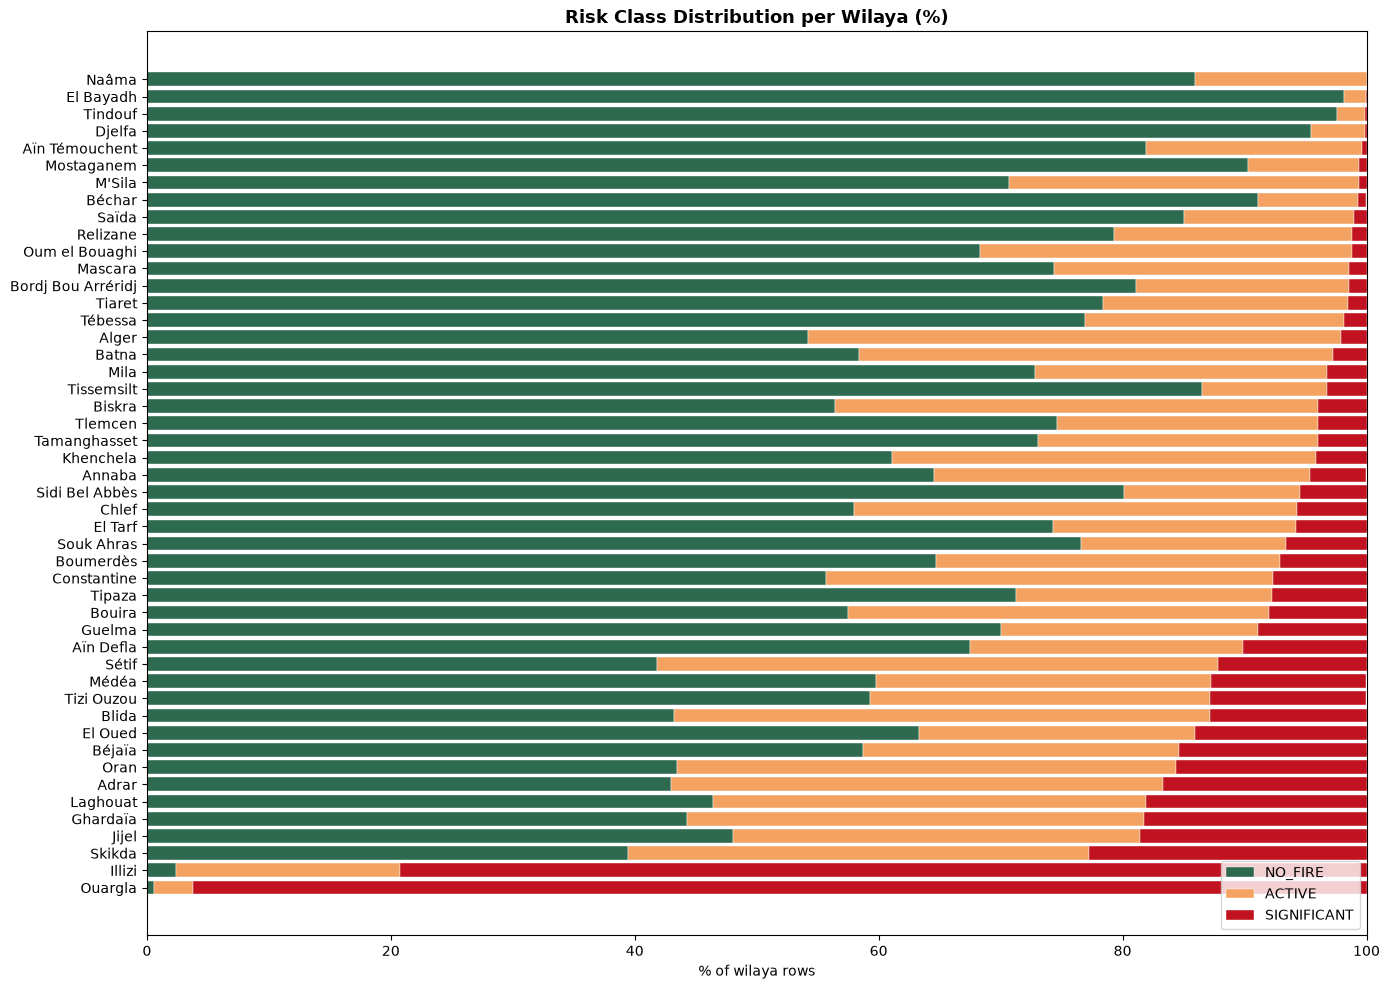

In [8]:
wilaya_balance = (df.groupby(["wilaya_name","fire_risk_class"])
                  .size().unstack(fill_value=0))
wilaya_balance_pct = wilaya_balance.div(wilaya_balance.sum(axis=1), axis=0) * 100
wilaya_balance_pct = wilaya_balance_pct.sort_values(2, ascending=False)

fig, ax = plt.subplots(figsize=(14, 10))
bottom = np.zeros(len(wilaya_balance_pct))
for cls in range(3):
    if cls in wilaya_balance_pct.columns:
        ax.barh(wilaya_balance_pct.index,
                wilaya_balance_pct[cls].values,
                left=bottom, color=COLORS[cls],
                label=RISK_LABELS[cls], edgecolor="white", linewidth=0.3)
        bottom += wilaya_balance_pct[cls].values
ax.set_title("Risk Class Distribution per Wilaya (%)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("% of wilaya rows")
ax.legend(loc="lower right", fontsize=10)
plt.tight_layout()
plt.savefig(OUT_DIR / "08_wilaya_class_balance.png", dpi=150)
plt.show()

In [9]:
print("=" * 60)
print("EDA SUMMARY — KEY FINDINGS")
print("=" * 60)

# Most fire-prone wilaya
top_wilaya = (df[df["fire_risk_class"] > 0]
              .groupby("wilaya_name").size()
              .idxmax())
print(f"\n1. Most fire-prone wilaya : {top_wilaya}")

# Peak fire month
peak_month = (df[df["fire_risk_class"] > 0]
              .groupby("month").size().idxmax())
print(f"2. Peak fire month        : {month_names.get(peak_month, peak_month)}")

# Best single predictor (MI)
print(f"3. Top MI feature         : {mi_series.idxmax()}")

# FWI signal
fwi_fire    = df.loc[df["fire_risk_class"] > 0, "FWI"].mean()
fwi_nofire  = df.loc[df["fire_risk_class"] == 0, "FWI"].mean()
print(f"4. Mean FWI fire days     : {fwi_fire:.1f}")
print(f"   Mean FWI no-fire days  : {fwi_nofire:.1f}")
print(f"   Δ FWI                  : +{fwi_fire - fwi_nofire:.1f}")

# Most active year
top_year = (df[df["fire_risk_class"] > 0]
            .groupby("year").size().idxmax())
print(f"5. Most active year       : {top_year}")

print("\n→ Proceed to 03_feature_engineering.ipynb")
print("=" * 60)

EDA SUMMARY — KEY FINDINGS

1. Most fire-prone wilaya : Ouargla
2. Peak fire month        : Aug
3. Top MI feature         : NBR
4. Mean FWI fire days     : 44.8
   Mean FWI no-fire days  : 36.4
   Δ FWI                  : +8.3
5. Most active year       : 2025

→ Proceed to 03_feature_engineering.ipynb
